<a href="https://colab.research.google.com/github/VitorSoaresGoncalves/CalculoNumerico/blob/main/ATV1_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identificação e divisão de tarefas

**Integrantes:**
- Letíca Yumi Matsune - RA: 176562
- Vitor Soares Gonçalves - RA: 176545

## Divisão das tarefas

### Letíca
- Parte A — Truncamento e arredondamento
  - Cálculo das aproximações
  - Cálculo dos erros absoluto, relativo e percentual
  - Tabela de resultados
  - Gráficos de erro absoluto
  - Resposta da questão sobre arredondamento e truncamento
- Parte B — Medidas de pressão arterial
  - Construção das quatro séries de dados
  - Cálculo de média, mínimo, máximo, amplitude e desvio-padrão
  - Cálculo dos erros das médias
  - Gráficos das quatro séries
  - Gráficos dos erros
  - Histogramas
  - Análise da representação inteira

### Vitor
- Parte C — Vazão em um tubo de pequeno diâmetro
  - Cálculo da vazão pela equação de Hagen–Poiseuille
  - Análise de arredondamento e truncamento das variáveis
  - Cálculo dos erros
  - Análise da sensibilidade da vazão ao raio
  - Gráficos de Q × r e dos erros
- Parte D — Escoamento em um nanocateter
  - Cálculo da vazão
  - Análise do erro geométrico
  - Comparação com a aproximação linear
  - Comparação entre float32 e float64
  - Análise de cancelamento
  - Explicação do fenômeno físico
- Parte E — Síntese visual
  - Quadro único de resultados
- Parte 8 — GIF demonstrativo
  - Geração e organização do GIF

### Tarefas realizadas em conjunto
- Revisão dos códigos
- Conferência dos cálculos, tabelas e unidades
- Revisão dos gráficos
- Revisão das respostas e conclusão
- Organização final do notebook para entrega

In [78]:
# Importa a biblioteca de funções matemáticas da linguagem Python.  (usado para funções matemáticas)
import math

# Importa a biblioteca NumPy e cria o apelido convencional np.  (usado para funções matemáticas)
import numpy as np

# Importa o módulo de gráficos pyplot e cria o apelido plt.  (usado para plotar gráfico)
import matplotlib.pyplot as plt

# Importa a biblioteca Pandas e cria o apelido pd.  (usado para plotar tabelas)
import pandas as pd

# Define um estilo visual claro para todos os gráficos do notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Importa a biblioteca imageio.v2 e cria o apelido imageio (usada para gifs)
import imageio.v2 as imageio

# Exibe uma mensagem para confirmar que a célula foi executada.
print("Ambiente preparado com sucesso!")

Ambiente preparado com sucesso!


In [79]:
#funções auxiliares

def truncar(x, n):  # Trunca o número x para n casas decimais,

    fator = 10 ** n
    return np.trunc(x * fator) / fator



# FUNÇÕES PARA CÁLCULO DOS ERROS


def erro_absoluto(x, x_aproximado):  # Calcula o erro absoluto.  Ea = |x - x̃|

    return abs(x - x_aproximado)


def erro_relativo(x, x_aproximado): # Calcula o erro relativo.  Er = |x - x̃| / |x|

    if x == 0:
        return np.nan

    return abs(x - x_aproximado) / abs(x)


def erro_percentual(x, x_aproximado): #Calcula o erro percentual. E% = 100 * Er

    Er = erro_relativo(x, x_aproximado)
    return 100 * Er

# Função de Hagen-Poiseuille

def vazao(r,mu,dp,L):
  return (np.pi * r**4 * dp)/ (8* mu * L)


,Caso,x (Referência),x' (Aproximado),Erro Absoluto ($E_a$),Erro Relativo ($E_r$),Erro Percentual ($E_\%)
1,$x_1 = 100$,100.0,101.0,1.0,0.0100,1.00%
2,$x_2 = 10$,10.0,11.0,1.0,0.1000,10.00%
3,$x_3 = 0.1$,0.1,1.1,1.0,10.0000,1000.00%


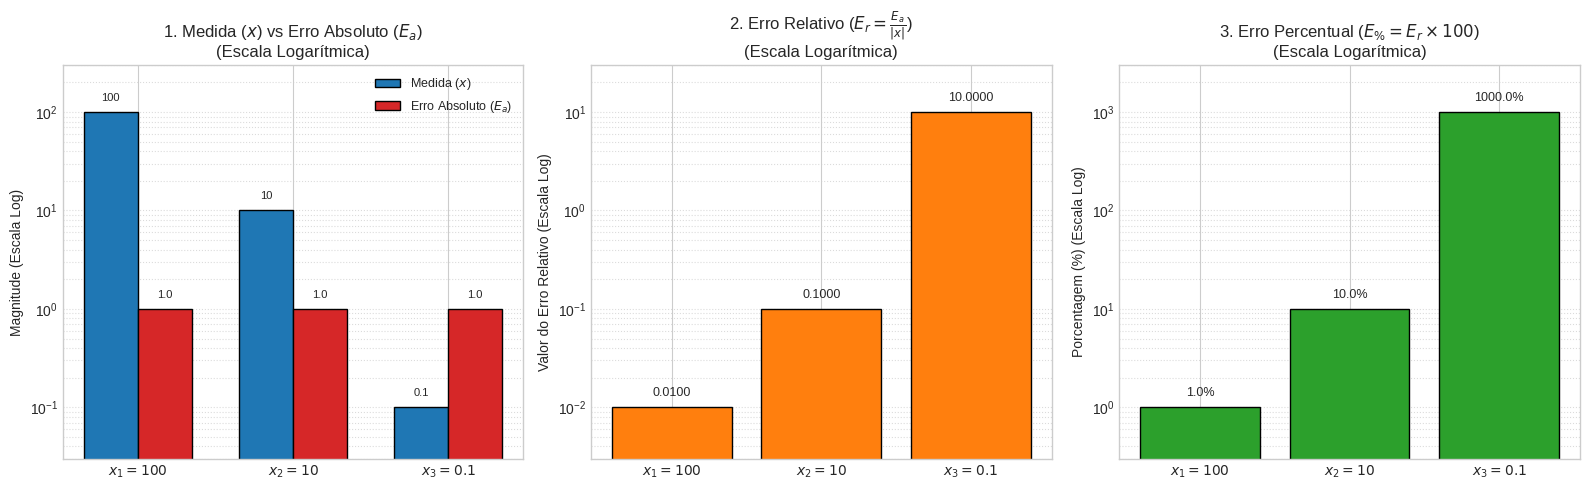

In [80]:
# ------------------------------------------------------------
# 1. Dados Numéricos
# ------------------------------------------------------------
casos = ["$x_1 = 100$", "$x_2 = 10$", "$x_3 = 0.1$"]
x_ref = np.array([100.0, 10.0, 0.1])
x_aprox = x_ref + 1.0  # Desvio constante de +1.0 em todas as escalas

# ------------------------------------------------------------
# 2. Cálculos dos Erros
# ------------------------------------------------------------
e_abs = np.abs(x_ref - x_aprox)
e_rel = e_abs / np.abs(x_ref)
e_pct = e_rel * 100

# Tabela resumo
df_erros = pd.DataFrame({
    "Caso": casos,
    "x (Referência)": x_ref,
    "x' (Aproximado)": x_aprox,
    r"Erro Absoluto ($E_a$)": e_abs,
    r"Erro Relativo ($E_r$)": e_rel,
    r"Erro Percentual ($E_\%)": e_pct,
})
df_erros.index = range(1, len(df_erros) + 1)

display(
    df_erros.style.format({
        "x (Referência)": "{:.1f}",
        "x' (Aproximado)": "{:.1f}",
        r"Erro Absoluto ($E_a$)": "{:.1f}",
        r"Erro Relativo ($E_r$)": "{:.4f}",
        r"Erro Percentual ($E_\%)": "{:.2f}%",
    })
)

# ------------------------------------------------------------
# 3. Gráficos Comparativos (Todos em Escala Logarítmica)
# ------------------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

indices = np.arange(len(casos))
largura = 0.35

# 1. Medida (x) vs Erro Absoluto (E_a) - Log
bars_ref = axs[0].bar(
    indices - largura / 2,
    x_ref,
    largura,
    label="Medida ($x$)",
    color="#1f77b4",
    edgecolor="black",
)
bars_err = axs[0].bar(
    indices + largura / 2,
    e_abs,
    largura,
    label=r"Erro Absoluto ($E_a$)",
    color="#d62728",
    edgecolor="black",
)

axs[0].set_title(
    r"1. Medida ($x$) vs Erro Absoluto ($E_a$)" + "\n(Escala Logarítmica)"
)
axs[0].set_ylabel("Magnitude (Escala Log)")
axs[0].set_xticks(indices)
axs[0].set_xticklabels(casos)
axs[0].set_yscale("log")
axs[0].set_ylim(
    min(x_ref.min(), e_abs.min()) * 0.3, max(x_ref.max(), e_abs.max()) * 3
)
axs[0].legend(fontsize=9)
axs[0].grid(True, axis="y", which="both", linestyle=":", alpha=0.7)

for b in bars_ref:
  h = b.get_height()
  val_str = f"{h:.1f}" if h < 1 else f"{h:.0f}"
  axs[0].text(
      b.get_x() + b.get_width() / 2,
      h * 1.3,
      val_str,
      ha="center",
      fontsize=8,
  )

for b in bars_err:
  h = b.get_height()
  axs[0].text(
      b.get_x() + b.get_width() / 2,
      h * 1.3,
      f"{h:.1f}",
      ha="center",
      fontsize=8,
  )

# 2. Erro Relativo - Log
bars2 = axs[1].bar(casos, e_rel, color="#ff7f0e", edgecolor="black")
axs[1].set_title(
    r"2. Erro Relativo ($E_r = \frac{E_a}{|x|}$)" + "\n(Escala Logarítmica)"
)
axs[1].set_ylabel("Valor do Erro Relativo (Escala Log)")
axs[1].set_yscale("log")
axs[1].set_ylim(e_rel.min() * 0.3, e_rel.max() * 3)
axs[1].grid(True, axis="y", which="both", linestyle=":", alpha=0.7)

for b in bars2:
  h = b.get_height()
  axs[1].text(
      b.get_x() + b.get_width() / 2,
      h * 1.3,
      f"{h:.4f}",
      ha="center",
      fontsize=9,
  )

# 3. Erro Percentual - Log
bars3 = axs[2].bar(casos, e_pct, color="#2ca02c", edgecolor="black")
axs[2].set_title(
    r"3. Erro Percentual ($E_\% = E_r \times 100$)" + "\n(Escala Logarítmica)"
)
axs[2].set_ylabel("Porcentagem (%) (Escala Log)")
axs[2].set_yscale("log")
axs[2].set_ylim(e_pct.min() * 0.3, e_pct.max() * 3)
axs[2].grid(True, axis="y", which="both", linestyle=":", alpha=0.7)

for b in bars3:
  h = b.get_height()
  axs[2].text(
      b.get_x() + b.get_width() / 2,
      h * 1.3,
      f"{h:.1f}%",
      ha="center",
      fontsize=9,
  )

plt.tight_layout()
plt.show()

# Parte A – truncamento e arredondamento

In [81]:

# valores fornecidos:

valores = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765
}

casas_decimais = [0, 1, 2, 3, 4]

# CÁLCULOS

resultados = []

for nome, x in valores.items():

    for n in casas_decimais:

        # Aproximações
        valor_truncado = truncar(x, n)
        valor_arredondado = round(x, n)

        # Erros do truncamento
        Ea_trunc = erro_absoluto(x, valor_truncado)
        Er_trunc = erro_relativo(x, valor_truncado)
        Ep_trunc = erro_percentual(x, valor_truncado)

        # Erros do arredondamento
        Ea_arred = erro_absoluto(x, valor_arredondado)
        Er_arred = erro_relativo(x, valor_arredondado)
        Ep_arred = erro_percentual(x, valor_arredondado)

        # Armazenando os resultados
        resultados.append({
            "Valor": nome,
            "Valor original": x,
            "n": n,

            "Truncamento": valor_truncado,
            "Ea truncamento": Ea_trunc,
            "Er truncamento": Er_trunc,
            "E% truncamento": Ep_trunc,

            "Arredondamento": valor_arredondado,
            "Ea arredondamento": Ea_arred,
            "Er arredondamento": Er_arred,
            "E% arredondamento": Ep_arred
        })

        tabela_resultados = pd.DataFrame(resultados)

# Mostrar todas as colunas e casas decimais
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.10f}")

display(tabela_resultados)

,Valor,Valor original,n,Truncamento,Ea truncamento,Er truncamento,E% truncamento,Arredondamento,Ea arredondamento,Er arredondamento,E% arredondamento
0,x1,3.1415926500,0,3.0000000000,0.1415926500,0.0450703404,4.5070340357,3.0000000000,0.1415926500,0.0450703404,4.5070340357
1,x1,3.1415926500,1,3.1000000000,0.0415926500,0.0132393517,1.3239351703,3.1000000000,0.0415926500,0.0132393517,1.3239351703
2,x1,3.1415926500,2,3.1400000000,0.0015926500,0.0005069562,0.0506956241,3.1400000000,0.0015926500,0.0005069562,0.0506956241
3,x1,3.1415926500,3,3.1410000000,0.0005926500,0.0001886464,0.0188646354,3.1420000000,0.0004073500,0.0001296635,0.0129663532
4,x1,3.1415926500,4,3.1415000000,0.0000926500,0.0000294914,0.0029491411,3.1416000000,0.0000073500,0.0000023396,0.0002339578
5,x2,98.7654300000,0,98.0000000000,0.7654300000,0.0077499789,0.7749978915,99.0000000000,0.2345700000,0.0023750213,0.2375021300
6,x2,98.7654300000,1,98.7000000000,0.0654300000,0.0006624788,0.0662478764,98.8000000000,0.0345700000,0.0003500213,0.0350021257
7,x2,98.7654300000,2,98.7600000000,0.0054300000,0.0000549788,0.0054978751,98.7700000000,0.0045700000,0.0000462713,0.0046271251
8,x2,98.7654300000,3,98.7650000000,0.0004300000,0.0000043538,0.0004353750,98.7650000000,0.0004300000,0.0000043538,0.0004353750
9,x2,98.7654300000,4,98.7654000000,0.0000300000,0.0000003038,0.0000303750,98.7654000000,0.0000300000,0.0000003038,0.0000303750


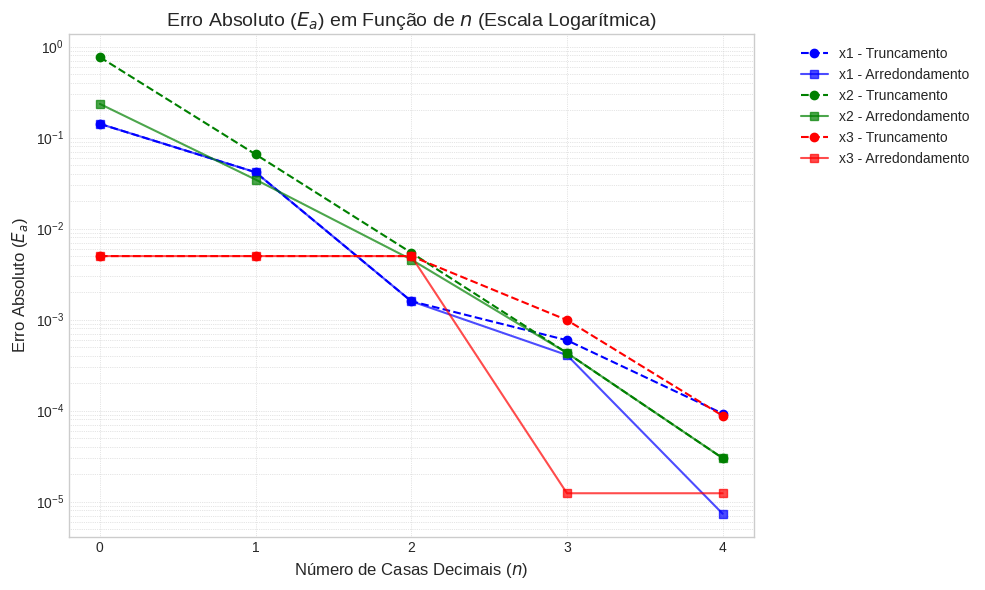

In [82]:
# Plot do gráfico

plt.figure(figsize=(10, 6))

# Cores distintas para cada variável
cores = {"x1": "blue", "x2": "green", "x3": "red"}

for nome in valores.keys():
  df_sub = tabela_resultados[tabela_resultados["Valor"] == nome]

  # Linha para Truncamento
  plt.plot(
      df_sub["n"],
      df_sub["Ea truncamento"],
      marker="o",
      linestyle="--",
      color=cores[nome],
      label=f"{nome} - Truncamento",
  )

  # Linha para Arredondamento
  plt.plot(
      df_sub["n"],
      df_sub["Ea arredondamento"],
      marker="s",
      linestyle="-",
      color=cores[nome],
      alpha=0.7,
      label=f"{nome} - Arredondamento",
  )

# Configurações do eixo logarítmico e formatação
plt.yscale("log")
plt.xlabel("Número de Casas Decimais ($n$)", fontsize=12)
plt.ylabel("Erro Absoluto ($E_a$)", fontsize=12)
plt.title(
    "Erro Absoluto ($E_a$) em Função de $n$ (Escala Logarítmica)", fontsize=14
)
plt.xticks(casas_decimais)
plt.grid(True, which="both", linestyle=":", linewidth=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

Arredondar sempre gera erro menor ou igual ao truncamento? Justifique com os
resultados.

R: De acordo como os resultados, arredondar sempre gera erro menor ou igual ao truncamento.  

# Parte B

In [83]:
# B.1 Representação das medidas

dados_originais = [
    121.7,
    120.4,
    122.1,
    119.8,
    121.2,
    120.9,
    122.4,
    121.0,
    120.2,
    121.5,
]

# 1. Construção das 3 séries solicitadas
series = {
    " Originais": dados_originais,
    " Arred. Inteiro (n=0)": [round(x) for x in dados_originais],
    " Trunc. Inteiro (n=0)": [math.trunc(x) for x in dados_originais],
}

# Média de referência (com todos os algarismos)
media_ref = np.mean(dados_originais)

# 2. Processamento estatístico e erros das médias
tabela_resultados = []

for nome, valores in series.items():
  arr = np.array(valores)
  media = np.mean(arr)
  minimo = np.min(arr)
  maximo = np.max(arr)
  amplitude = maximo - minimo
  desvio_padrao = np.std(arr, ddof=1)  # Desvio-padrão amostral

  # Cálculo dos erros em relação à média de referência
  Ea = abs(media_ref - media)
  Er = Ea / abs(media_ref)
  Ep = Er * 100

  tabela_resultados.append({
      "Série": nome,
      "Média (mmHg)": media,
      "Mínimo": minimo,
      "Máximo": maximo,
      "Amplitude": amplitude,
      "Desvio-Padrão Amostral": desvio_padrao,
      "Ea Média": Ea,
      "Er Média": Er,
      "E% Média (%)": Ep,
  })

df_parte_b = pd.DataFrame(tabela_resultados)
df_parte_b.index = range(1, len(df_parte_b) + 1)

# Exibição da tabela configurada
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
display(df_parte_b)

,Série,Média (mmHg),Mínimo,Máximo,Amplitude,Desvio-Padrão Amostral,Ea Média,Er Média,E% Média (%)
1,Originais,121.120000,119.800000,122.400000,2.600000,0.833733,0.000000,0.000000,0.000000
2,Arred. Inteiro (n=0),121.100000,120.000000,122.000000,2.000000,0.875595,0.020000,0.000165,0.016513
3,Trunc. Inteiro (n=0),120.700000,119.000000,122.000000,3.000000,0.948683,0.420000,0.003468,0.346764


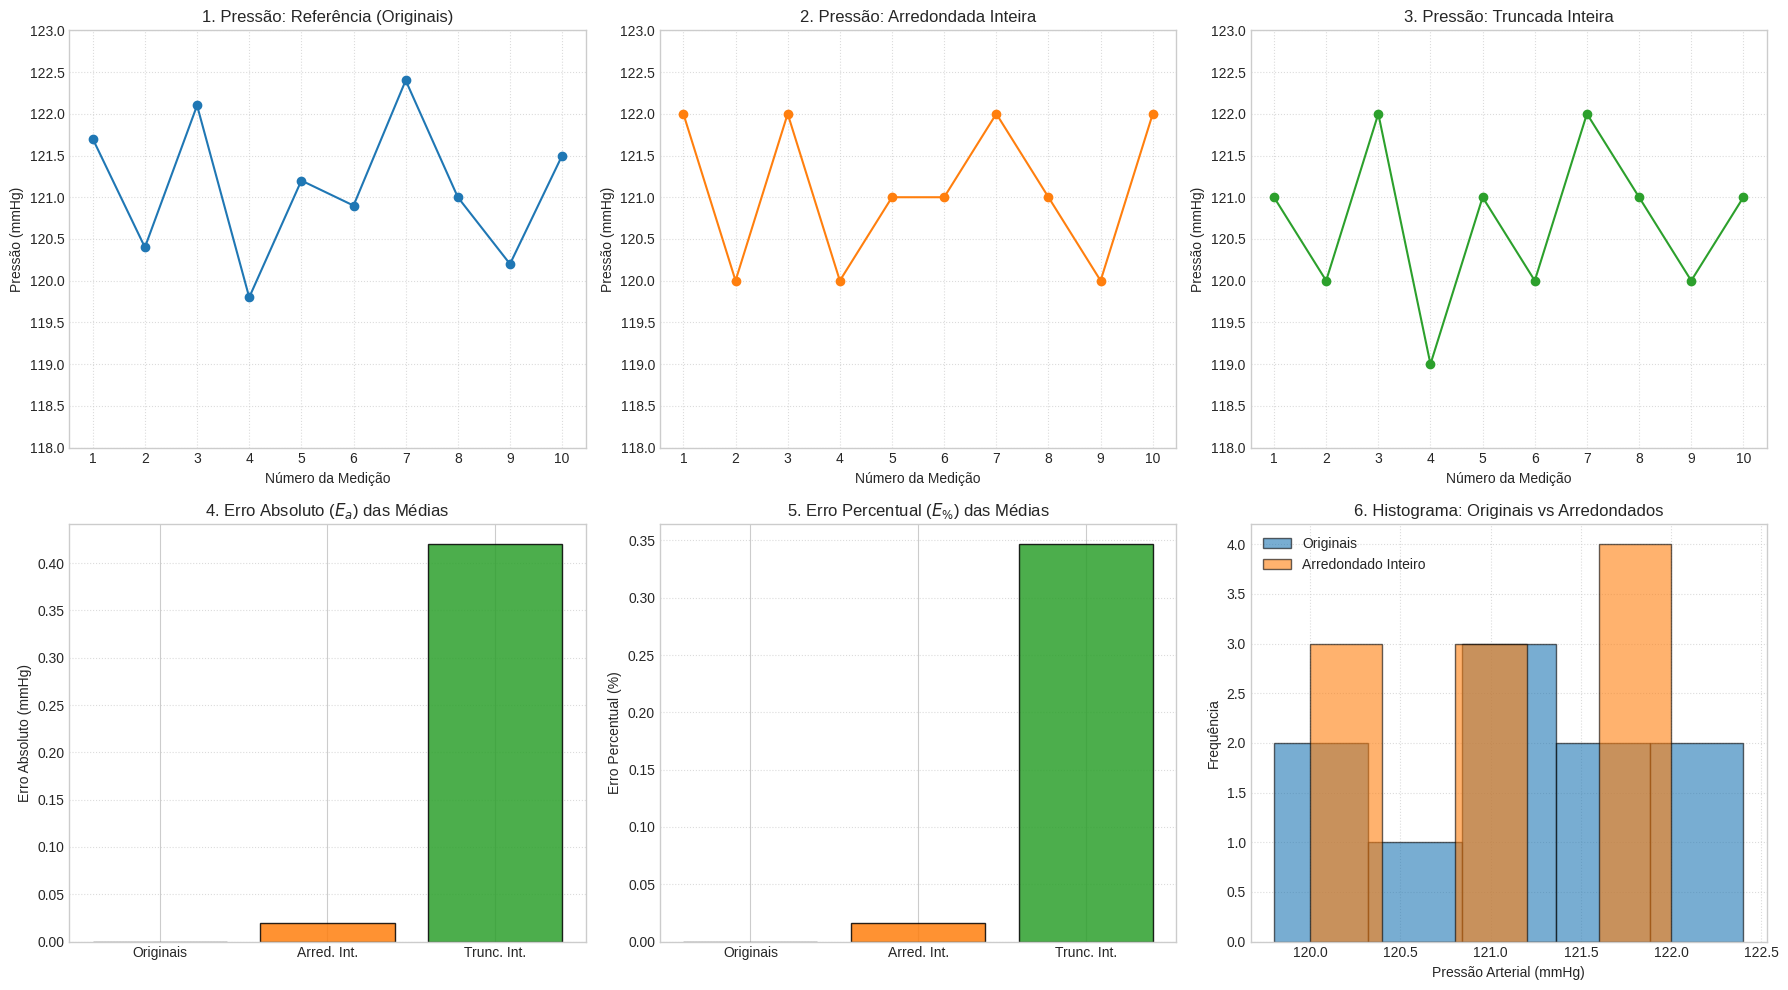

In [84]:
# Gráficos Obrigatórios (B.2) - Séries de Pressão Separadas

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

indices = np.arange(1, 11)
cores = ["#1f77b4", "#ff7f0e", "#2ca02c"]
chaves_series = list(series.keys())

# ============================================================
# ESCALA Y COMUM E MAIS PRECISA PARA OS 3 PRIMEIROS GRÁFICOS
# ============================================================

# Junta todos os valores das três séries
todos_dados = np.concatenate([
    series[chaves_series[0]],
    series[chaves_series[1]],
    series[chaves_series[2]]
])

# Define os limites considerando todos os dados
y_min = np.floor(np.min(todos_dados) - 0.5)
y_max = np.ceil(np.max(todos_dados) + 0.5)

# Intervalo das marcações do eixo Y
passo_y = 0.5

# ============================================================
# 1. Medições: Referência (Originais)
# ============================================================

axs[0, 0].plot(
    indices,
    series[chaves_series[0]],
    marker="o",
    linestyle="-",
    color=cores[0]
)

axs[0, 0].set_title("1. Pressão: Referência (Originais)")
axs[0, 0].set_xlabel("Número da Medição")
axs[0, 0].set_ylabel("Pressão (mmHg)")
axs[0, 0].set_xticks(indices)

# Mesma escala Y
axs[0, 0].set_ylim(y_min, y_max)
axs[0, 0].set_yticks(np.arange(y_min, y_max + passo_y, passo_y))

axs[0, 0].grid(True, linestyle=":", alpha=0.7)


# ============================================================
# 2. Medições: Arredondada
# ============================================================

axs[0, 1].plot(
    indices,
    series[chaves_series[1]],
    marker="o",
    linestyle="-",
    color=cores[1]
)

axs[0, 1].set_title("2. Pressão: Arredondada Inteira")
axs[0, 1].set_xlabel("Número da Medição")
axs[0, 1].set_ylabel("Pressão (mmHg)")
axs[0, 1].set_xticks(indices)

# Mesma escala Y
axs[0, 1].set_ylim(y_min, y_max)
axs[0, 1].set_yticks(np.arange(y_min, y_max + passo_y, passo_y))

axs[0, 1].grid(True, linestyle=":", alpha=0.7)


# ============================================================
# 3. Medições: Truncada
# ============================================================

axs[0, 2].plot(
    indices,
    series[chaves_series[2]],
    marker="o",
    linestyle="-",
    color=cores[2]
)

axs[0, 2].set_title("3. Pressão: Truncada Inteira")
axs[0, 2].set_xlabel("Número da Medição")
axs[0, 2].set_ylabel("Pressão (mmHg)")
axs[0, 2].set_xticks(indices)

# Mesma escala Y
axs[0, 2].set_ylim(y_min, y_max)
axs[0, 2].set_yticks(np.arange(y_min, y_max + passo_y, passo_y))

axs[0, 2].grid(True, linestyle=":", alpha=0.7)


# ============================================================
# EXTRAÇÃO DOS ERROS
# ============================================================

eas = [d["Ea Média"] for d in tabela_resultados]
eps = [d["E% Média (%)"] for d in tabela_resultados]

nomes_series = ["Originais", "Arred. Int.", "Trunc. Int."]


# ============================================================
# 4. Gráfico de barras dos erros absolutos
# ============================================================

axs[1, 0].bar(
    nomes_series,
    eas,
    color=cores,
    alpha=0.85,
    edgecolor="black"
)

axs[1, 0].set_title("4. Erro Absoluto ($E_a$) das Médias")
axs[1, 0].set_ylabel("Erro Absoluto (mmHg)")
axs[1, 0].grid(True, axis="y", linestyle=":", alpha=0.7)


# ============================================================
# 5. Gráfico de barras dos erros percentuais
# ============================================================

axs[1, 1].bar(
    nomes_series,
    eps,
    color=cores,
    alpha=0.85,
    edgecolor="black"
)

axs[1, 1].set_title(r"5. Erro Percentual ($E_\%$) das Médias")
axs[1, 1].set_ylabel("Erro Percentual (%)")
axs[1, 1].grid(True, axis="y", linestyle=":", alpha=0.7)


# ============================================================
# 6. Histograma: Originais vs Arredondados
# ============================================================

axs[1, 2].hist(
    series[chaves_series[0]],
    bins=5,
    alpha=0.6,
    label="Originais",
    color=cores[0],
    edgecolor="black"
)

axs[1, 2].hist(
    series[chaves_series[1]],
    bins=5,
    alpha=0.6,
    label="Arredondado Inteiro",
    color=cores[1],
    edgecolor="black"
)

axs[1, 2].set_title("6. Histograma: Originais vs Arredondados")
axs[1, 2].set_xlabel("Pressão Arterial (mmHg)")
axs[1, 2].set_ylabel("Frequência")
axs[1, 2].legend()
axs[1, 2].grid(True, linestyle=":", alpha=0.7)


# ============================================================
# AJUSTE FINAL
# ============================================================

plt.tight_layout()
plt.show()

todos_dados = np.concatenate([
    series[chaves_series[0]],
    series[chaves_series[1]],
    series[chaves_series[2]]
])

y_min = np.floor(np.min(todos_dados) - 0.5)
y_max = np.ceil(np.max(todos_dados) + 0.5)

passo_y = 0.5

Explique se a representação inteira é suficiente para preservar a média e a variabilidade
desta pequena amostra. Não faça interpretação médica dos valores.

R: Sim, visto que os erros no caso de truncar (pior caso), o erro absoluto não ultrapassa 0.4 unidades e o percentual é menor que 0.5% acredito que a representação inteira não traria problemas para a interpretação dos dados.

# Parte C – vazão em um tubo de pequeno diâmetro

In [85]:
# C.1 - Precisão das Variáveis (Unidades em mL/min e mL/s)

# Dados de entrada
r_mm = 0.80
L = 0.20
mu = 3.5e-3
dp = 1200

r = r_mm / 1000

# Vazão de referência (m³/s)
Q_ref_m3s = vazao(r, mu, dp, L)

# Conversões de unidade
Q_ref_mLmin = Q_ref_m3s * 6e7
Q_ref_mLs = Q_ref_m3s * 1e6

print("Vazão de referência:")
print(f"Q = {Q_ref_mLmin:.4e} mL/min")
print(f"Q = {Q_ref_mLs:.4e} mL/s\n")

# Aproximações
r_arred = round(r_mm, 1) / 1000
r_trunc = truncar(r_mm, 1) / 1000

mu_arred = round(mu, 3)
mu_trunc = truncar(mu, 3)

dp_arred = round(dp / 100) * 100
dp_trunc = truncar(dp / 100, 0) * 100

cenarios = {
    "Referência": (r, mu, dp),
    "r arredondado": (r_arred, mu, dp),
    "r truncado": (r_trunc, mu, dp),
    "μ arredondada": (r, mu_arred, dp),
    "μ truncada": (r, mu_trunc, dp),
    "Δp arredondada": (r, mu, dp_arred),
    "Δp truncada": (r, mu, dp_trunc),
    "Todas arredondadas": (r_arred, mu_arred, dp_arred),
    "Todas truncadas": (r_trunc, mu_trunc, dp_trunc),
}

resultados = []

for nome, (r_i, mu_i, dp_i) in cenarios.items():
  Q_m3s = vazao(r_i, mu_i, dp_i, L)
  Q_mLmin = Q_m3s * 6e7

  e_abs_mLmin = erro_absoluto(Q_ref_mLmin, Q_mLmin)
  e_pct = 100 * (erro_absoluto(Q_ref_m3s, Q_m3s) / abs(Q_ref_m3s))

  resultados.append([nome, Q_mLmin, e_abs_mLmin, e_pct])

tabela = pd.DataFrame(
    resultados,
    columns=[
        "Cenário",
        "Q (mL/min)",
        "Erro Absoluto (mL/min)",
        "Erro Percentual (%)",
    ],
)
tabela.index = range(1, len(tabela) + 1)

formato_estilo = {
    "Q (mL/min)": "{:.4e}",
    "Erro Absoluto (mL/min)": "{:.4e}",
    "Erro Percentual (%)": "{:.4e}%",
}

print("--- Tabela C.1: Sensibilidade da Vazão (em mL/min) ---")
display(tabela.style.format(formato_estilo))

Vazão de referência:
Q = 1.6545e+01 mL/min
Q = 2.7574e-01 mL/s

--- Tabela C.1: Sensibilidade da Vazão (em mL/min) ---


,Cenário,Q (mL/min),Erro Absoluto (mL/min),Erro Percentual (%)
1,Referência,1.6545e+01,0.0000e+00,0.0000e+00%
2,r arredondado,1.6545e+01,0.0000e+00,0.0000e+00%
3,r truncado,1.6545e+01,0.0000e+00,0.0000e+00%
4,μ arredondada,1.4476e+01,2.0681e+00,1.2500e+01%
5,μ truncada,1.9302e+01,2.7574e+00,1.6667e+01%
6,Δp arredondada,1.6545e+01,0.0000e+00,0.0000e+00%
7,Δp truncada,1.6545e+01,0.0000e+00,0.0000e+00%
8,Todas arredondadas,1.4476e+01,2.0681e+00,1.2500e+01%
9,Todas truncadas,1.9302e+01,2.7574e+00,1.6667e+01%


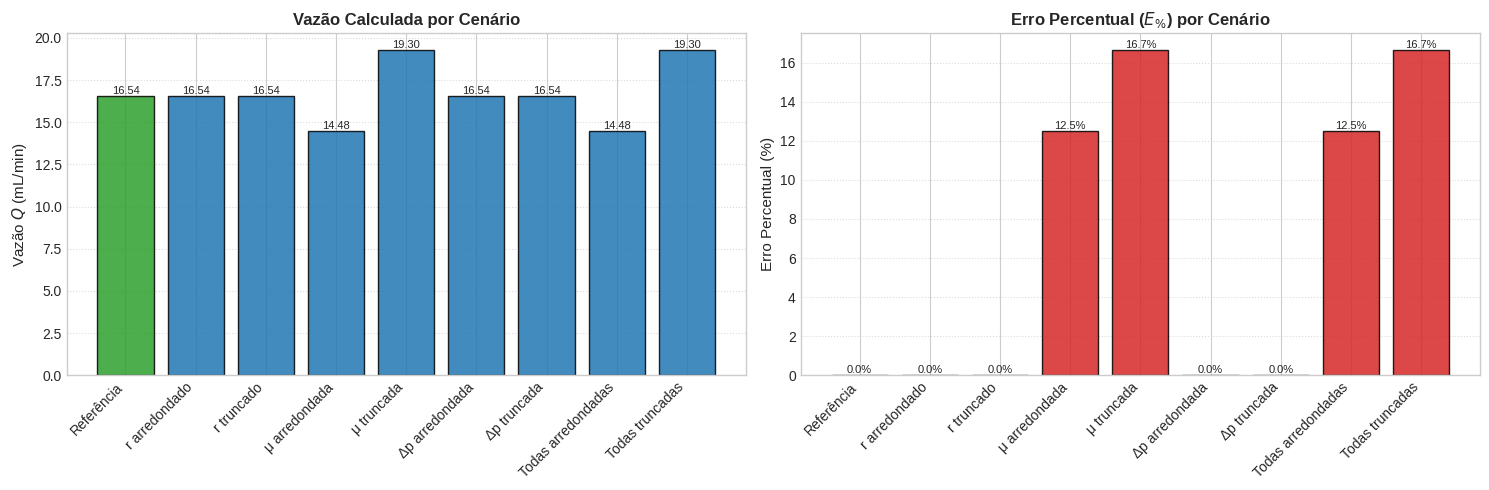

In [86]:
# ============================================================
# Gráfico C.1 - Sensibilidade do Cálculo da Vazão (mL/min)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Extração de dados da tabela C.1
cenarios_nomes = tabela["Cenário"].values
vazoes_mLmin = tabela["Q (mL/min)"].values
erros_pct = tabela["Erro Percentual (%)"].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Comparação das Vazões por Cenário
cores_q = [
    "#2ca02c" if "Referência" in c else "#1f77b4" for c in cenarios_nomes
]
bars1 = ax1.bar(
    cenarios_nomes, vazoes_mLmin, color=cores_q, alpha=0.85, edgecolor="black"
)
ax1.set_title("Vazão Calculada por Cenário", fontsize=12, fontweight="bold")
ax1.set_ylabel("Vazão $Q$ (mL/min)", fontsize=11)

# Define a posição das marcas antes de atribuir os nomes dos rótulos
ax1.set_xticks(range(len(cenarios_nomes)))
ax1.set_xticklabels(cenarios_nomes, rotation=45, ha="right")
ax1.grid(True, axis="y", linestyle=":", alpha=0.7)

# Adiciona o valor no topo de cada barra
for bar in bars1:
  yval = bar.get_height()
  ax1.text(
      bar.get_x() + bar.get_width() / 2,
      yval,
      f"{yval:.2f}",
      ha="center",
      va="bottom",
      fontsize=8,
  )

# 2. Impacto do Erro Percentual (%) por Cenário
cores_e = [
    "#d62728" if e > 10 else "#ff7f0e" if e > 0 else "#2ca02c"
    for e in erros_pct
]
bars2 = ax2.bar(
    cenarios_nomes, erros_pct, color=cores_e, alpha=0.85, edgecolor="black"
)
ax2.set_title(
    r"Erro Percentual ($E_\%$) por Cenário", fontsize=12, fontweight="bold"
)
ax2.set_ylabel("Erro Percentual (%)", fontsize=11)

# Define a posição das marcas antes de atribuir os nomes dos rótulos
ax2.set_xticks(range(len(cenarios_nomes)))
ax2.set_xticklabels(cenarios_nomes, rotation=45, ha="right")
ax2.grid(True, axis="y", linestyle=":", alpha=0.7)

# Adiciona o percentual no topo de cada barra
for bar in bars2:
  yval = bar.get_height()
  ax2.text(
      bar.get_x() + bar.get_width() / 2,
      yval,
      f"{yval:.1f}%",
      ha="center",
      va="bottom",
      fontsize=8,
  )

plt.tight_layout()
plt.show()

In [87]:
# C.2 - Sensibilidade da vazão do raio

# ------------------------------------------------------------
# Dados constantes
# ------------------------------------------------------------

L = 0.20              # m
mu = 3.5e-3           # Pa.s
dp = 1200             # Pa

# Raios de 0,70 a 0,90 mm
r_mm = np.arange(0.70, 0.901, 0.01)

# ------------------------------------------------------------
# Arredondamento e truncamento
# ------------------------------------------------------------

# Arredondamento matemático para uma casa decimal
# (evita problemas do arredondamento binário do Python)
r_arred_mm = np.floor(r_mm * 10 + 0.5) / 10

# Truncamento para uma casa decimal
r_trunc_mm = np.floor(r_mm * 10) / 10

# ------------------------------------------------------------
# Vazões
# ------------------------------------------------------------

Q_ref = vazao(r_mm, mu, dp, L)

Q_arred = vazao(r_arred_mm, mu, dp, L)

Q_trunc = vazao(r_trunc_mm, mu, dp, L)

# ------------------------------------------------------------
# Erros
# ------------------------------------------------------------

# Erro absoluto
erro_abs_arred = np.abs(Q_arred - Q_ref)
erro_abs_trunc = np.abs(Q_trunc - Q_ref)

# Erro relativo
erro_rel_arred = erro_abs_arred / np.abs(Q_ref)
erro_rel_trunc = erro_abs_trunc / np.abs(Q_ref)

# Erro percentual
erro_pct_arred = erro_rel_arred * 100
erro_pct_trunc = erro_rel_trunc * 100

# ------------------------------------------------------------
# Tabela de resultados
# ------------------------------------------------------------

tabela = pd.DataFrame({
    "r original (mm)": r_mm,
    "r arredondado (mm)": r_arred_mm,
    "r truncado (mm)": r_trunc_mm,
    "Q referência (m³/s)": Q_ref,
    "Q arredondado (m³/s)": Q_arred,
    "Q truncado (m³/s)": Q_trunc,
    "Erro abs. arred. (m³/s)": erro_abs_arred,
    "Erro abs. trunc. (m³/s)": erro_abs_trunc,
    "Erro rel. arred.": erro_rel_arred,
    "Erro rel. trunc.": erro_rel_trunc,
    "Erro % arred.": erro_pct_arred,
    "Erro % trunc.": erro_pct_trunc
})

display(tabela.round(10))

,r original (mm),r arredondado (mm),r truncado (mm),Q referência (m³/s),Q arredondado (m³/s),Q truncado (m³/s),Erro abs. arred. (m³/s),Erro abs. trunc. (m³/s),Erro rel. arred.,Erro rel. trunc.,Erro % arred.,Erro % trunc.
0,0.700000,0.700000,0.700000,161634.942027,161634.942027,161634.942027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.710000,0.700000,0.700000,171071.036454,161634.942027,161634.942027,9436.094426,9436.094426,0.055159,0.055159,5.515892,5.515892
2,0.720000,0.700000,0.700000,180914.375535,161634.942027,161634.942027,19279.433508,19279.433508,0.106567,0.106567,10.656662,10.656662
3,0.730000,0.700000,0.700000,191176.511358,161634.942027,161634.942027,29541.569331,29541.569331,0.154525,0.154525,15.452510,15.452510
4,0.740000,0.700000,0.700000,201869.157574,161634.942027,161634.942027,40234.215547,40234.215547,0.199308,0.199308,19.930838,19.930838
5,0.750000,0.800000,0.700000,213004.189404,275742.075195,161634.942027,62737.885792,51369.247376,0.294538,0.241165,29.453827,24.116543
6,0.760000,0.800000,0.700000,224593.643634,275742.075195,161634.942027,51148.431561,62958.701607,0.227738,0.280323,22.773766,28.032272
7,0.770000,0.800000,0.700000,236649.718622,275742.075195,161634.942027,39092.356573,75014.776595,0.165191,0.316987,16.519080,31.698654
8,0.780000,0.800000,0.700000,249184.774290,275742.075195,161634.942027,26557.300905,87549.832262,0.106577,0.351345,10.657674,35.134503
9,0.790000,0.800000,0.700000,262211.332128,275742.075195,161634.942027,13530.743067,100576.390101,0.051602,0.383570,5.160243,38.356996


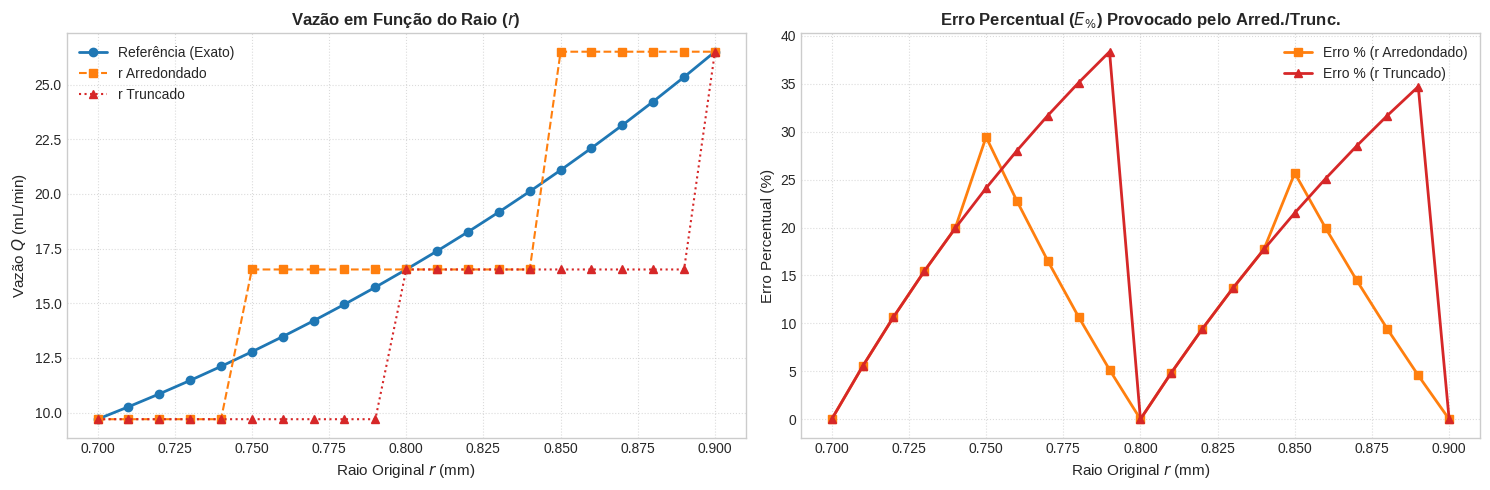

In [88]:
# ============================================================
# Gráfico C.2 - Sensibilidade em Função da Variação do Raio
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Conversão dos raios para metros no cálculo da vazão
r_m = r_mm / 1000
r_arred_m = r_arred_mm / 1000
r_trunc_m = r_trunc_mm / 1000

# Recálculo das vazões em mL/min
Q_ref_mLmin = vazao(r_m, mu, dp, L) * 6e7
Q_arred_mLmin = vazao(r_arred_m, mu, dp, L) * 6e7
Q_trunc_mLmin = vazao(r_trunc_m, mu, dp, L) * 6e7

# Erros percentuais
e_pct_arred = np.abs(Q_arred_mLmin - Q_ref_mLmin) / Q_ref_mLmin * 100
e_pct_trunc = np.abs(Q_trunc_mLmin - Q_ref_mLmin) / Q_ref_mLmin * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Curvas de Vazão vs. Raio Original
ax1.plot(
    r_mm,
    Q_ref_mLmin,
    label="Referência (Exato)",
    color="#1f77b4",
    linewidth=2,
    marker="o",
)
ax1.plot(
    r_mm,
    Q_arred_mLmin,
    label="r Arredondado",
    color="#ff7f0e",
    linestyle="--",
    marker="s",
)
ax1.plot(
    r_mm,
    Q_trunc_mLmin,
    label="r Truncado",
    color="#d62728",
    linestyle=":",
    marker="^",
)

ax1.set_title(
    "Vazão em Função do Raio ($r$)", fontsize=12, fontweight="bold"
)
ax1.set_xlabel("Raio Original $r$ (mm)", fontsize=11)
ax1.set_ylabel("Vazão $Q$ (mL/min)", fontsize=11)
ax1.grid(True, linestyle=":", alpha=0.7)
ax1.legend(fontsize=10)

# 2. Erro Percentual Gerado pelas Aproximações do Raio
ax2.plot(
    r_mm,
    e_pct_arred,
    label="Erro % (r Arredondado)",
    color="#ff7f0e",
    linewidth=2,
    marker="s",
)
ax2.plot(
    r_mm,
    e_pct_trunc,
    label="Erro % (r Truncado)",
    color="#d62728",
    linewidth=2,
    marker="^",
)

ax2.set_title(
    r"Erro Percentual ($E_\%$) Provocado pelo Arred./Trunc.",
    fontsize=12,
    fontweight="bold",
)
ax2.set_xlabel("Raio Original $r$ (mm)", fontsize=11)
ax2.set_ylabel("Erro Percentual (%)", fontsize=11)
ax2.grid(True, linestyle=":", alpha=0.7)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

Explique por que o erro no raio é amplificado na vazão. Relacione sua resposta ao expoente
quatro.

R: O erro no raio é amplificado na vazão porque o raio aparece na equação elevado à quarta potência. Portanto, uma pequena alteração em \(r\) tem um efeito muito maior sobre \(Q\) do que uma alteração de mesma proporção em uma variável que aparece apenas na primeira potência.

# Parte D - Escoamento em um Nanocateter

--- D.1 Amostra dos Cálculos de Erro Geométrico ---


,Δr (nm),r_ (nm),r+ (nm),Q(r_) (m³/s),Q(r) (m³/s),Q(r+) (m³/s),Ea Máx (m³/s),Er Máx,E% Máx (%),E% Linear (%)
1,1.000000e-01,4.990000e+01,5.010000e+01,3.478276e-19,3.506242e-19,3.534376e-19,2.813420e-21,8.024032e-03,8.024032e-01,8.000000e-01
2,2.000000e-01,4.980000e+01,5.020000e+01,3.450478e-19,3.506242e-19,3.562679e-19,5.643737e-21,1.609626e-02,1.609626e+00,1.600000e+00
3,3.000000e-01,4.970000e+01,5.030000e+01,3.422846e-19,3.506242e-19,3.591152e-19,8.491019e-21,2.421687e-02,2.421687e+00,2.400000e+00
4,4.000000e-01,4.960000e+01,5.040000e+01,3.395381e-19,3.506242e-19,3.619795e-19,1.135533e-20,3.238605e-02,3.238605e+00,3.200000e+00
5,5.000000e-01,4.950000e+01,5.050000e+01,3.368082e-19,3.506242e-19,3.648609e-19,1.423675e-20,4.060401e-02,4.060401e+00,4.000000e+00
6,6.000000e-01,4.940000e+01,5.060000e+01,3.340947e-19,3.506242e-19,3.677595e-19,1.713533e-20,4.887093e-02,4.887093e+00,4.800000e+00
7,7.000000e-01,4.930000e+01,5.070000e+01,3.313977e-19,3.506242e-19,3.706753e-19,2.005115e-20,5.718701e-02,5.718701e+00,5.600000e+00
8,8.000000e-01,4.920000e+01,5.080000e+01,3.287171e-19,3.506242e-19,3.736085e-19,2.298427e-20,6.555245e-02,6.555245e+00,6.400000e+00
9,9.000000e-01,4.910000e+01,5.090000e+01,3.260527e-19,3.506242e-19,3.765590e-19,2.593477e-20,7.396743e-02,7.396743e+00,7.200000e+00
10,1.000000e+00,4.900000e+01,5.100000e+01,3.234046e-19,3.506242e-19,3.795269e-19,2.890271e-20,8.243216e-02,8.243216e+00,8.000000e+00


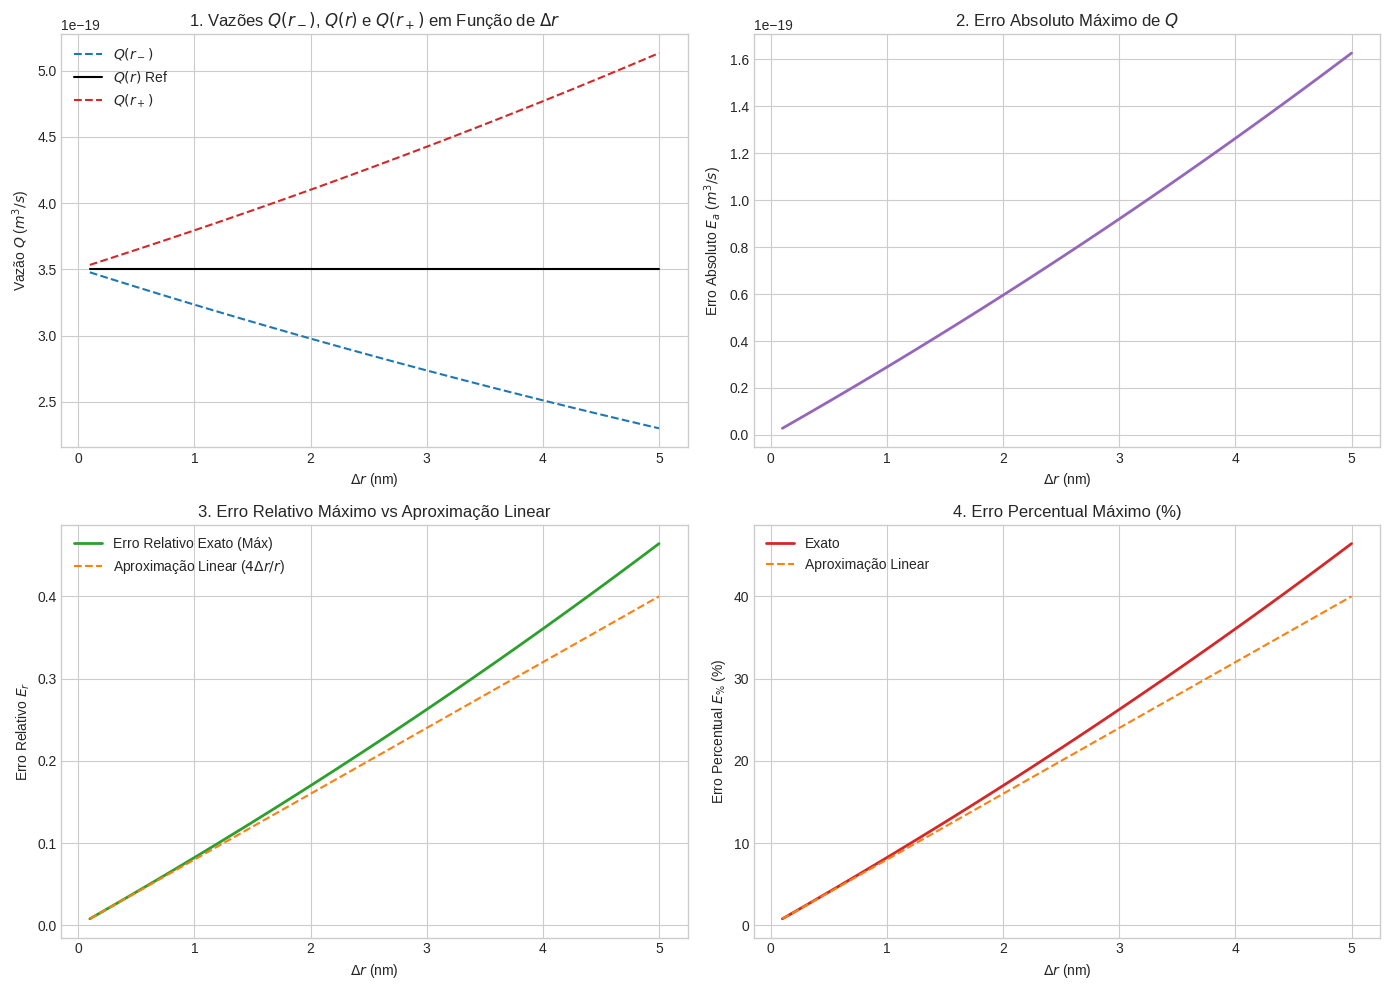

In [89]:
pd.reset_option("display.float_format")
# Parâmetros numéricos do nanocateter (convertidos para o SI)
r_base = 50e-9  # 50 nm -> metros
L = 10e-6  # 10 µm -> metros
mu = 3.5e-3  # 3.5 x 10^-3 Pa.s
dp = 5000  # 5000 Pa

# Vazão de referência usando a função predefinida vazao()
Q_ref = vazao(r_base, mu, dp, L)

# D.1 Erro Geométrico: Variação de dr de 0.1 nm a 5.0 nm
delta_r_nm = np.arange(0.1, 5.1, 0.1)
delta_r_m = delta_r_nm * 1e-9

r_minus = r_base - delta_r_m
r_plus = r_base + delta_r_m

# Cálculo das vazões extremas utilizando a função predefinida
Q_minus = vazao(r_minus, mu, dp, L)
Q_plus = vazao(r_plus, mu, dp, L)

# Cálculo dos erros absolutos utilizando a função predefinida erro_absoluto()
Ea_minus = erro_absoluto(Q_ref, Q_minus)
Ea_plus = erro_absoluto(Q_ref, Q_plus)
Ea_max = np.maximum(Ea_minus, Ea_plus)

# Erros relativo e percentual calculados de forma vetorial direta
Er_max = Ea_max / abs(Q_ref)
Ep_max = 100 * Er_max

# Aproximação linear: dQ/Q ≈ 4 * (dr/r)
Er_aprox = 4 * (delta_r_m / r_base)
Ep_aprox = 100 * Er_aprox

# Tabela D.1 com amostra dos resultados (Índice iniciando em 1)
df_d1 = pd.DataFrame({
    "Δr (nm)": delta_r_nm,
    "r_ (nm)": r_minus * 1e9,
    "r+ (nm)": r_plus * 1e9,
    "Q(r_) (m³/s)": Q_minus,
    "Q(r) (m³/s)": Q_ref,
    "Q(r+) (m³/s)": Q_plus,
    "Ea Máx (m³/s)": Ea_max,
    "Er Máx": Er_max,
    "E% Máx (%)": Ep_max,
    "E% Linear (%)": Ep_aprox,
})
df_d1.index = range(1, len(df_d1) + 1)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6e}")
print("--- D.1 Amostra dos Cálculos de Erro Geométrico ---")
display(df_d1.head(10))

# 4 Gráficos Solicitados na Parte D.1
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Gráfico de Q(r-), Q(r) e Q(r+)
axs[0, 0].plot(
    delta_r_nm, Q_minus, label=r"$Q(r_-)$", color="#1f77b4", linestyle="--"
)
axs[0, 0].plot(
    delta_r_nm,
    [Q_ref] * len(delta_r_nm),
    label=r"$Q(r)$ Ref",
    color="black",
    linewidth=1.5,
)
axs[0, 0].plot(
    delta_r_nm, Q_plus, label=r"$Q(r_+)$", color="#d62728", linestyle="--"
)
axs[0, 0].set_title(
    r"1. Vazões $Q(r_-)$, $Q(r)$ e $Q(r_+)$ em Função de $\Delta r$"
)
axs[0, 0].set_xlabel(r"$\Delta r$ (nm)")
axs[0, 0].set_ylabel(r"Vazão $Q$ ($m^3/s$)")
axs[0, 0].legend()

# 2. Erro Absoluto Máximo
axs[0, 1].plot(delta_r_nm, Ea_max, color="#9467bd", linewidth=2)
axs[0, 1].set_title(r"2. Erro Absoluto Máximo de $Q$")
axs[0, 1].set_xlabel(r"$\Delta r$ (nm)")
axs[0, 1].set_ylabel(r"Erro Absoluto $E_a$ ($m^3/s$)")

# 3. Erro Relativo Máximo vs Aproximação Linear
axs[1, 0].plot(
    delta_r_nm,
    Er_max,
    label="Erro Relativo Exato (Máx)",
    color="#2ca02c",
    linewidth=2,
)
axs[1, 0].plot(
    delta_r_nm,
    Er_aprox,
    label=r"Aproximação Linear ($4 \Delta r / r$)",
    color="#ff7f0e",
    linestyle="--",
)
axs[1, 0].set_title(r"3. Erro Relativo Máximo vs Aproximação Linear")
axs[1, 0].set_xlabel(r"$\Delta r$ (nm)")
axs[1, 0].set_ylabel(r"Erro Relativo $E_r$")
axs[1, 0].legend()

# 4. Erro Percentual Máximo
axs[1, 1].plot(delta_r_nm, Ep_max, label="Exato", color="#d62728", linewidth=2)
axs[1, 1].plot(
    delta_r_nm,
    Ep_aprox,
    label="Aproximação Linear",
    color="#ff7f0e",
    linestyle="--",
)
axs[1, 1].set_title(r"4. Erro Percentual Máximo (%)")
axs[1, 1].set_xlabel(r"$\Delta r$ (nm)")
axs[1, 1].set_ylabel(r"Erro Percentual $E_\%$ (%)")
axs[1, 1].legend()

plt.tight_layout()
plt.show()

In [90]:
# D.2 Precisão Computacional (float32 vs float64) e Perda de Significância

# Variáveis em precisão float32
r_f32, L_f32, mu_f32, dp_f32 = (
    np.float32(50e-9),
    np.float32(10e-6),
    np.float32(3.5e-3),
    np.float32(5000),
)
r4_f32 = r_f32**4
Q_f32 = vazao(r_f32, mu_f32, dp_f32, L_f32)
eps_f32 = np.finfo(np.float32).eps

# Variáveis em precisão float64
r_f64, L_f64, mu_f64, dp_f64 = (
    np.float64(50e-9),
    np.float64(10e-6),
    np.float64(3.5e-3),
    np.float64(5000),
)
r4_f64 = r_f64**4
Q_f64 = vazao(r_f64, mu_f64, dp_f64, L_f64)
eps_f64 = np.finfo(np.float64).eps

# Utilizando as funções predefinidas para obter a diferença absoluta e relativa
diff_abs_Q = erro_absoluto(Q_f64, Q_f32)
diff_rel_Q = erro_relativo(Q_f64, Q_f32)

df_precisao = pd.DataFrame({
    "Variável / Métrica": [
        "Epsilon da Máquina (eps)",
        "r⁴ (m⁴)",
        "Vazão Q (m³/s)",
    ],
    "float32": [eps_f32, r4_f32, Q_f32],
    "float64": [eps_f64, r4_f64, Q_f64],
    "Diferença Absoluta": [
        ('-'),
        erro_absoluto(r4_f64, r4_f32),
        diff_abs_Q,
    ],
    "Diferença Relativa": [
        ('-'),
        erro_relativo(r4_f64, r4_f32),
        diff_rel_Q,
    ],
})
df_precisao.index = range(1, len(df_precisao) + 1)

print("--- D.2 Tabela 1: Comparação de Precisão (float32 vs float64) ---")
display(df_precisao)

# Análise de Cancelamento (δ1 vs δ2)
expoentes = np.arange(1, 16)
razoes_dr_r = 10.0 ** (-expoentes)

delta1_list = []
delta2_list = []

for dr_r in razoes_dr_r:
  dr = dr_r * r_base
  # δ1: Subtração direta de vazões
  Q_var = vazao(r_base + dr, mu, dp, L)
  d1 = (Q_var - Q_ref) / Q_ref

  # δ2: Expansão algébrica exata
  d2 = (1 + dr_r) ** 4 - 1

  delta1_list.append(d1)
  delta2_list.append(d2)

df_cancelamento = pd.DataFrame({
    "Δr / r": razoes_dr_r,
    "δ1 (Subtração Direta)": delta1_list,
    "δ2 (Fórmula Algébrica)": delta2_list,
    "Erro Relativo entre δ1 e δ2": [
        erro_relativo(d2, d1) if d2 != 0 else 0
        for d1, d2 in zip(delta1_list, delta2_list)
    ],
})
df_cancelamento.index = range(1, len(df_cancelamento) + 1)

print("\n--- D.2 Tabela 2: Análise de perda de significância por Cancelamento (δ1 vs δ2) ---")
display(df_cancelamento)

--- D.2 Tabela 1: Comparação de Precisão (float32 vs float64) ---


,Variável / Métrica,float32,float64,Diferença Absoluta,Diferença Relativa
1,Epsilon da Máquina (eps),1.192093e-07,2.220446e-16,-,-
2,r⁴ (m⁴),6.250000e-30,6.250000e-30,3.959774e-37,6.335639e-08
3,Vazão Q (m³/s),3.506242e-19,3.506242e-19,5.228628e-26,1.491234e-07



--- D.2 Tabela 2: Análise de perda de significância por Cancelamento (δ1 vs δ2) ---


,Δr / r,δ1 (Subtração Direta),δ2 (Fórmula Algébrica),Erro Relativo entre δ1 e δ2
1,1.000000e-01,4.641000e-01,4.641000e-01,1.794155e-15
2,1.000000e-02,4.060401e-02,4.060401e-02,8.886376e-15
3,1.000000e-03,4.006004e-03,4.006004e-03,5.586098e-14
4,1.000000e-04,4.000600e-04,4.000600e-04,3.238568e-14
5,1.000000e-05,4.000060e-05,4.000060e-05,1.252895e-11
6,1.000000e-06,4.000006e-06,4.000006e-06,6.527925e-11
7,1.000000e-07,4.000001e-07,4.000001e-07,1.153196e-09
8,1.000000e-08,4.000000e-08,4.000000e-08,4.503110e-09
9,1.000000e-09,4.000000e-09,4.000000e-09,1.603534e-07
10,1.000000e-10,4.000000e-10,4.000000e-10,1.129849e-08


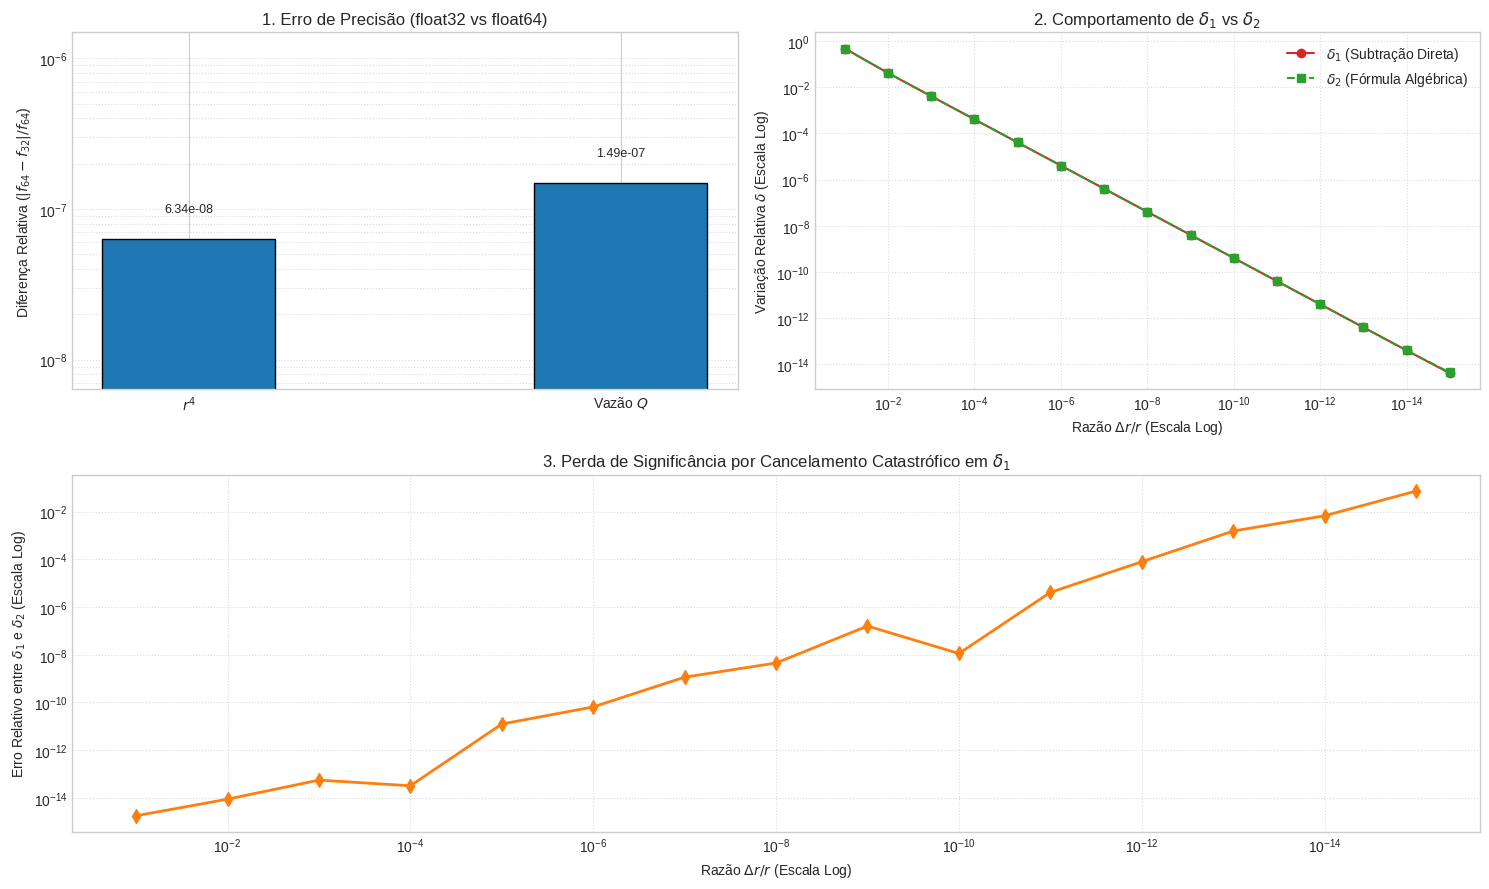

In [91]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 4. Geração dos Gráficos Comparativos
# ------------------------------------------------------------
fig = plt.figure(figsize=(15, 9))

# 4.1. Tabela 1: Impacto da Precisão em float32 vs float64
ax1 = fig.add_subplot(2, 2, 1)
vars_t1 = ["$r^4$", "Vazão $Q$"]
diff_rel_t1 = [erro_relativo(r4_f64, r4_f32), diff_rel_Q]

bars = ax1.bar(
    vars_t1, diff_rel_t1, color="#1f77b4", edgecolor="black", width=0.4
)
ax1.set_ylabel("Diferença Relativa ($|f_{64} - f_{32}| / f_{64}$)")
ax1.set_title("1. Erro de Precisão (float32 vs float64)")
ax1.set_yscale("log")
ax1.set_ylim(min(diff_rel_t1) * 0.1, max(diff_rel_t1) * 10)
ax1.grid(True, axis="y", which="both", linestyle=":", alpha=0.7)

for b in bars:
  h = b.get_height()
  ax1.text(
      b.get_x() + b.get_width() / 2,
      h * 1.5,
      f"{h:.2e}",
      ha="center",
      fontsize=9,
  )

# 4.2. Tabela 2: Comparação Direta entre δ1 e δ2
ax2 = fig.add_subplot(2, 2, 2)
ax2.loglog(
    razoes_dr_r,
    delta1_list,
    "o-",
    label=r"$\delta_1$ (Subtração Direta)",
    color="#d62728",
)
ax2.loglog(
    razoes_dr_r,
    delta2_list,
    "s--",
    label=r"$\delta_2$ (Fórmula Algébrica)",
    color="#2ca02c",
)
ax2.set_xlabel(r"Razão $\Delta r / r$ (Escala Log)")
ax2.set_ylabel(r"Variação Relativa $\delta$ (Escala Log)")
ax2.set_title(r"2. Comportamento de $\delta_1$ vs $\delta_2$")
ax2.invert_xaxis()  # Exibe de 10^-1 até 10^-15
ax2.grid(True, which="both", linestyle=":", alpha=0.7)
ax2.legend()

# 4.3. Tabela 2: Perda de Significância (Erro Relativo entre δ1 e δ2)
ax3 = fig.add_subplot(2, 1, 2)
erros_rel_cancelamento = df_cancelamento["Erro Relativo entre δ1 e δ2"]

ax3.loglog(
    razoes_dr_r,
    erros_rel_cancelamento,
    "d-",
    color="#ff7f0e",
    linewidth=2,
    markersize=7,
)
ax3.set_xlabel(r"Razão $\Delta r / r$ (Escala Log)")
ax3.set_ylabel(r"Erro Relativo entre $\delta_1$ e $\delta_2$ (Escala Log)")
ax3.set_title(
    r"3. Perda de Significância por Cancelamento Catastrófico em $\delta_1$"
)
ax3.invert_xaxis()  # Exibe de 10^-1 até 10^-15
ax3.grid(True, which="both", linestyle=":", alpha=0.7)

plt.tight_layout()
plt.show()

A partir do 1.000000e-11 é possível notar um erro relativo considerável e que cresce muito rapidamente, logo é possível determinar que existe uma perda considerável para Δr / r menores que 1.000000e-11.

D.3 Fenômeno físico

Explique, em um parágrafo, que a redução da escala aumenta a razão superfície/volume e torna os efeitos viscosos e de parede mais importantes.

R: Quando o tamanho do sistema diminui, a relação entre a superfície e o volume aumenta. Por isso, os efeitos da parede e da viscosidade ficam mais importantes no escoamento. A equação de Hagen–Poiseuille pode fornecer um resultado com muitas casas decimais, mas isso não garante que o modelo represente exatamente o fenômeno físico. Portanto, precisão numérica e validade do modelo são conceitos diferentes.

# Parte E - Síntese Visual

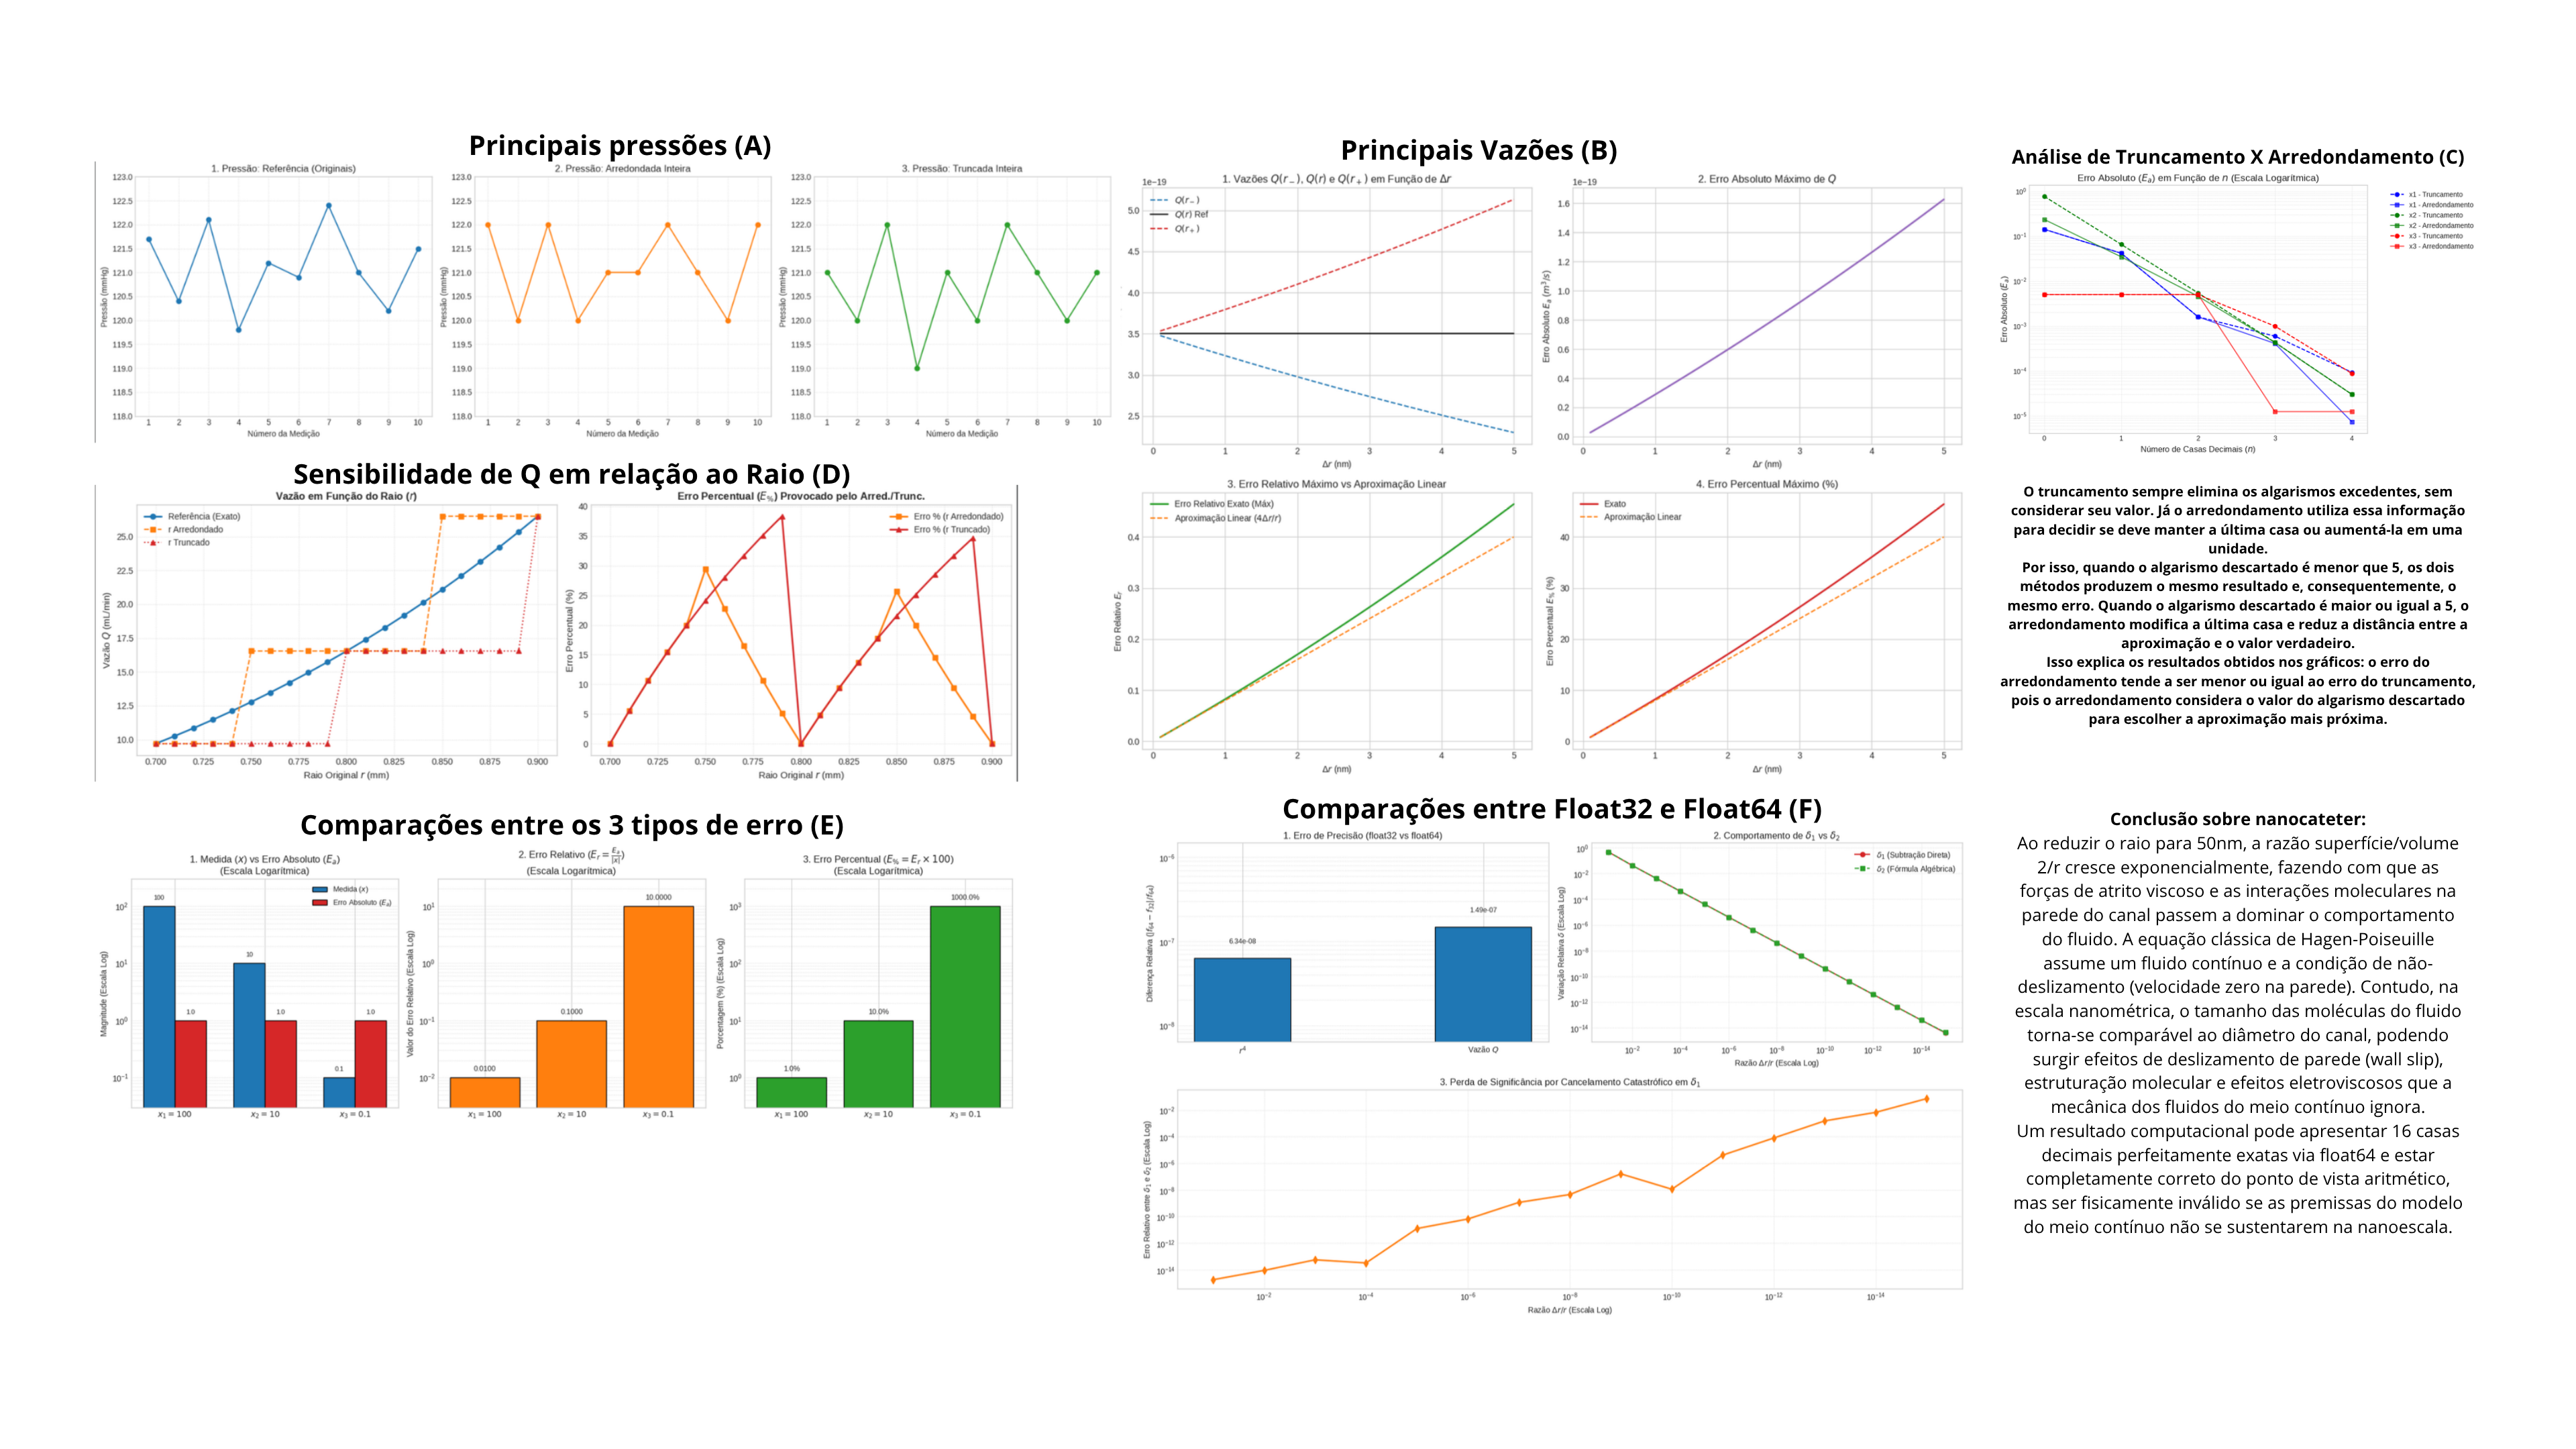

In [93]:
from IPython.display import display, Image

display(Image(filename=list(uploaded.keys())[0]))

# Para melhor visualização recomento clicar com o botão direito do mouse na imagem, abrir em uma nova guia e então dar zoom caso necessário.

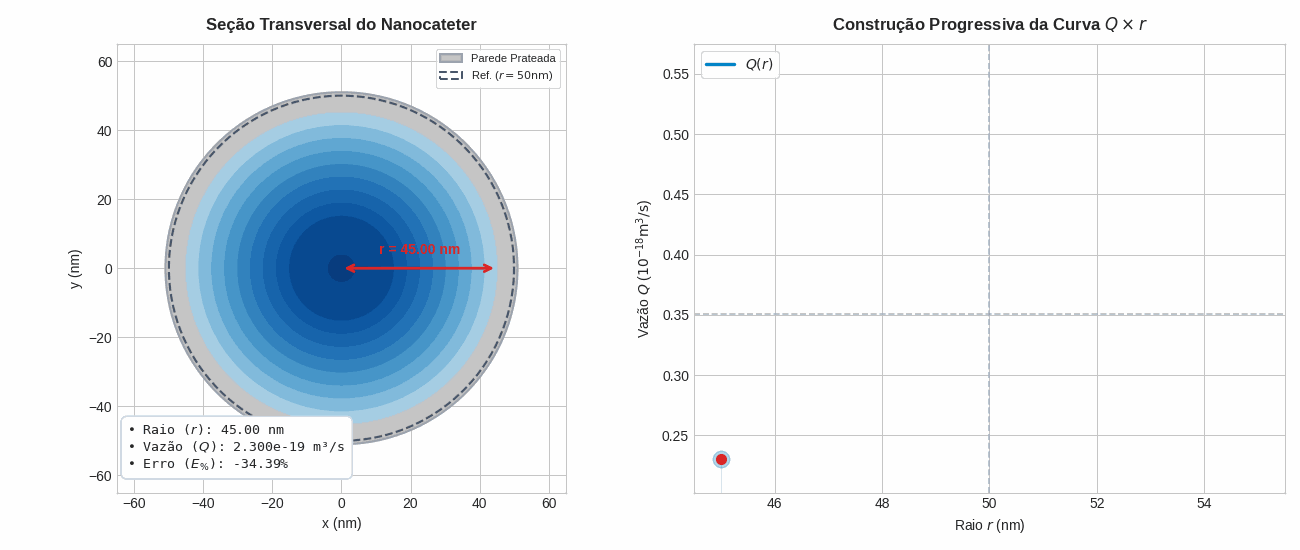

In [94]:
import io
import math
import imageio.v2 as imageio
from IPython.display import Image, display
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# ------------------------------------------------------------
# 1. Parâmetros Físicos do Nanocateter
# ------------------------------------------------------------
L = 10e-6
mu = 3.5e-3
dp = 5000
r_ref = 50e-9


def vazao(r):
  return (np.pi * (r**4) * dp) / (8 * mu * L)


Q_ref = vazao(r_ref)

# ------------------------------------------------------------
# 2. Preparação dos Dados (Sequência estritamente linear: 45 -> 55 nm em 60 quadros)
# ------------------------------------------------------------
n_frames = 60
r_array_nm = np.linspace(45, 55, n_frames)
r_array_m = r_array_nm * 1e-9
Q_array = vazao(r_array_m)
erro_pct = ((Q_array - Q_ref) / Q_ref) * 100

frames = []

# ------------------------------------------------------------
# 3. Renderização dos Quadros
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), dpi=100)

for i in range(n_frames):
  ax1.clear()
  ax2.clear()

  r_nm = r_array_nm[i]
  Q_val = Q_array[i]
  err = erro_pct[i]

  # --- SUBPLOT 1: Seção Transversal ---
  ax1.set_aspect("equal")
  ax1.set_xlim(-65, 65)
  ax1.set_ylim(-65, 65)
  ax1.set_title(
      "Seção Transversal do Nanocateter",
      fontsize=12,
      fontweight="bold",
      pad=10,
  )
  ax1.set_xlabel("x (nm)")
  ax1.set_ylabel("y (nm)")

  # Parede sólida do cateter em tom Prateado
  espessura_parede = 6.0
  parede_ext = plt.Circle(
      (0, 0),
      r_nm + espessura_parede,
      color="#C0C0C0",
      ec="#9CA3AF",
      lw=1.5,
      zorder=1,
      label="Parede Prateada",
  )
  ax1.add_patch(parede_ext)

  # Fluido interno exclusivamente em tons de azul (cm.Blues)
  n_camadas = 12
  for j in range(n_camadas, 0, -1):
    r_camada = r_nm * (j / n_camadas)
    v_rel = 1 - (j / n_camadas) ** 2
    cor_azul = cm.Blues(0.35 + 0.60 * v_rel)
    camada = plt.Circle((0, 0), r_camada, color=cor_azul, zorder=2)
    ax1.add_patch(camada)

  # Círculo de referência (50 nm)
  ref_circle = plt.Circle(
      (0, 0),
      50,
      fill=False,
      color="#475569",
      linestyle="--",
      linewidth=1.5,
      zorder=3,
      label="Ref. ($r = 50\\mathrm{nm}$)",
  )
  ax1.add_patch(ref_circle)

  # Vetor vermelho do raio e texto dinâmico "r = X nm"
  ax1.annotate(
      "",
      xy=(r_nm, 0),
      xytext=(0, 0),
      arrowprops=dict(
          arrowstyle="<->", color="#dc2626", lw=2, mutation_scale=12
      ),
      zorder=4,
  )
  ax1.text(
      r_nm / 2,
      4,
      f"r = {r_nm:.2f} nm",
      color="#dc2626",
      fontweight="bold",
      fontsize=10,
      ha="center",
      zorder=5,
  )

  ax1.legend(loc="upper right", fontsize=8, frameon=True, facecolor="white")

  # Card de Métricas
  text_str = (
      f"• Raio ($r$): {r_nm:.2f} nm\n"
      f"• Vazão ($Q$): {Q_val:.3e} m³/s\n"
      f"• Erro ($E_\\%$): {err:+.2f}%"
  )
  ax1.text(
      -62,
      -58,
      text_str,
      fontsize=9.5,
      family="monospace",
      bbox=dict(boxstyle="round,pad=0.5", fc="#f8fafc", ec="#cbd5e1", lw=1.2),
      zorder=6,
  )

  # --- SUBPLOT 2: Curva Q x r ---
  ax2.set_xlim(44.5, 55.5)
  ax2.set_ylim(min(Q_array) * 1e18 * 0.88, max(Q_array) * 1e18 * 1.12)
  ax2.set_title(
      r"Construção Progressiva da Curva $Q \times r$",
      fontsize=12,
      fontweight="bold",
      pad=10,
  )
  ax2.set_xlabel("Raio $r$ (nm)")
  ax2.set_ylabel(r"Vazão $Q$ ($10^{-18} \mathrm{m}^3/\mathrm{s}$)")

  ax2.axvline(50, color="#94a3b8", linestyle="--", alpha=0.7, lw=1.2)
  ax2.axhline(Q_ref * 1e18, color="#94a3b8", linestyle="--", alpha=0.7, lw=1.2)

  ax2.fill_between(
      r_array_nm[: i + 1],
      0,
      Q_array[: i + 1] * 1e18,
      color="#0284c7",
      alpha=0.15,
  )
  ax2.plot(
      r_array_nm[: i + 1],
      Q_array[: i + 1] * 1e18,
      color="#0284c7",
      lw=2.5,
      label="$Q(r)$",
  )

  ax2.plot(r_nm, Q_val * 1e18, "o", color="#0284c7", ms=12, alpha=0.3)
  ax2.plot(r_nm, Q_val * 1e18, "o", color="#dc2626", ms=7)

  ax2.legend(loc="upper left", frameon=True, facecolor="white")

  plt.tight_layout()

  fig.canvas.draw()
  image = np.asarray(fig.canvas.buffer_rgba()).copy()
  frames.append(image)

plt.close(fig)

# ------------------------------------------------------------
# 4. Salvamento e Exibição do GIF
# ------------------------------------------------------------
imageio.mimsave("nanocateter_escoamento.gif", frames, fps=15, loop=0)

display(Image(filename="nanocateter_escoamento.gif", embed=True))